<a href="https://colab.research.google.com/github/AR-Ashik-9997/Phitron-practice-problem/blob/main/SVC_of_Breast_Cancer_Prediction_Model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Required Libraries

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score,recall_score

Load Dataset

In [91]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset/breast cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Data Preprocessing

In [92]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


drop that irrelavent data

In [93]:
df.drop('Unnamed: 32',axis=1,inplace=True)

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [95]:
df.duplicated().sum()

np.int64(0)

convert Target labels

In [96]:
le=LabelEncoder()
df['diagnosis']=le.fit_transform(df['diagnosis'])

Feature & Target Separation

In [97]:
x=df.drop('diagnosis',axis=1)
y=df['diagnosis']

Feature Scaling and encoding the target data

In [98]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

Data Splitting

In [99]:
X_train,X_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42)

Visualization

Feature Correlation (Heatmap)

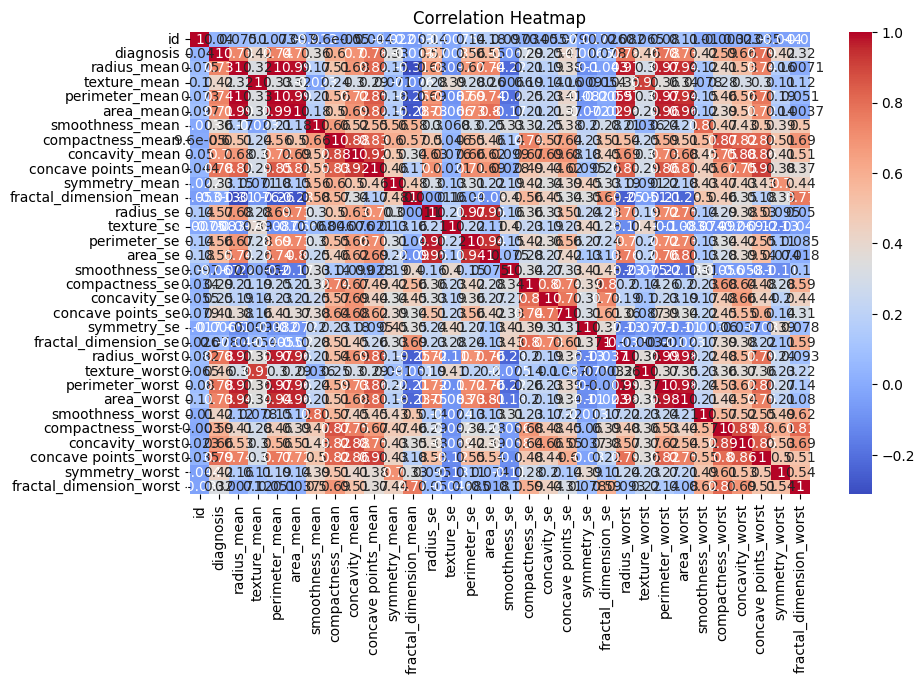

In [100]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Histogram (Single Feature)

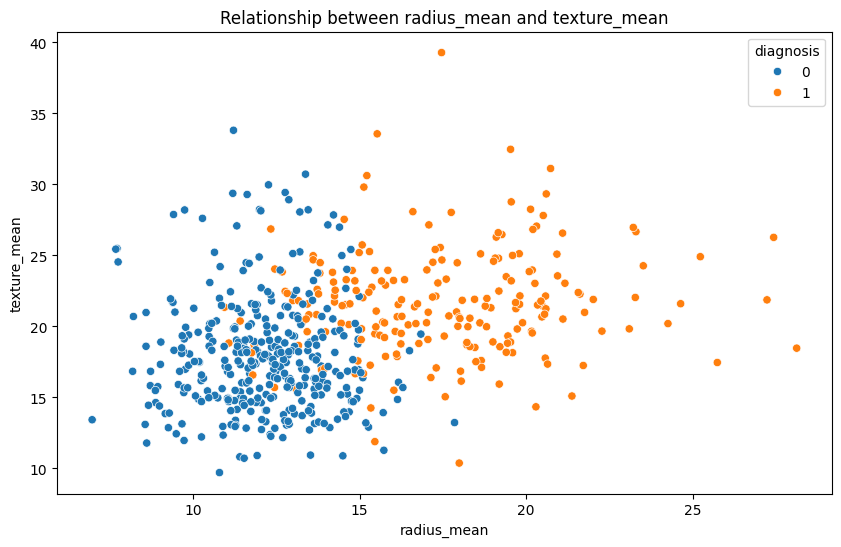

In [101]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='radius_mean',y='texture_mean',data=df,hue='diagnosis')
plt.title('Relationship between radius_mean and texture_mean')
plt.xlabel('radius_mean')
plt.ylabel('texture_mean')
plt.show()

Model Building

In [102]:
svc_model=SVC(kernel='linear',C=1.0)

Train and evaluate using accuracy

In [103]:
svc=svc_model.fit(X_train,y_train)
y_pred = svc.predict(X_test)

Evaluting

In [104]:
acc=accuracy_score(y_test,y_pred)
prec=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)

print(f'Accuracy: {acc*100:.2f}%')
print(f'Precision Score: {prec*100:.2f}%')
print(f'Recall Score: {recall*100:.2f}%')

Accuracy: 95.61%
Precision Score: 93.18%
Recall Score: 95.35%


## overfitting Testing

In [105]:
train_pred = svc_model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

test_pred = svc_model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

overfitting_test=train_acc-test_acc
if(overfitting_test>0.5*100):
  print(f"overfitting percentage: {overfitting_test*100:.2f}%")
else:
  print("No overfitting")

No overfitting


SVC model performed very well. SVC achieved higher accuracy (95.61%). showing that the data works well with a simple linear model and that the preprocessing was done correctly.